In [1]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import shutil
import os
import json

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
CONFIG = {
    "drive_train_dir": "/content/drive/MyDrive/Emotions Dataset/train",
    "drive_validation_dir": "/content/drive/MyDrive/Emotions Dataset/test",
    "local_train_dir": "/content/train",
    "local_validation_dir": "/content/validation",
    "image_size": (224, 224),
    "batch_size": 32,
    "num_classes": 3,
    "class_names": ["angry", "happy", "sad"],
    "epochs": 30,
    "learning_rate": 0.001,
    "model_type": "baseline_normal"
}

In [4]:
print("Copying data from Google Drive to local Colab storage")

# Copy data from Drive to local Colab storage for faster access
if not os.path.exists(CONFIG["local_train_dir"]):
    print("Copying training data to local storage")
    shutil.copytree(CONFIG["drive_train_dir"], CONFIG["local_train_dir"])
    print("Training data copied successfully")

if not os.path.exists(CONFIG["local_validation_dir"]):
    print("Copying validation data to local storage")
    shutil.copytree(CONFIG["drive_validation_dir"], CONFIG["local_validation_dir"])
    print("Validation data copied successfully")

Copying data from Google Drive to local Colab storage
Copying training data to local storage
Training data copied successfully
Copying validation data to local storage
Validation data copied successfully


In [5]:
print("Step 1: Loading pre-trained EfficientNetB0")

# Create the model architecture without weights
base_model = EfficientNetB0(weights=None,
                            include_top=False)

# Build the model with the correct shape
batch_input_shape = (None, 256, 256, 3)
base_model.build(batch_input_shape)

# Load the weights
weights_path = tf.keras.utils.get_file(
    'efficientnetb0_notop.h5',
    'https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5',
    cache_subdir='models'
)
base_model.load_weights(weights_path)

base_model.trainable = False

print(f"Number of layers: {len(base_model.layers)}")

Step 1: Loading pre-trained EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Number of layers: 237


In [6]:
print("Step 2: Preparing data generators")

# Standard data augmentation, no low-light techniques
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.15,
    shear_range=0.1,
    fill_mode='nearest'
)

# Validation data generator (standard preprocessing)
validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    CONFIG["local_train_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    classes=CONFIG["class_names"]
)

validation_generator = validation_datagen.flow_from_directory(
    CONFIG["local_validation_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    classes=CONFIG["class_names"]
)

print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Class indices: {train_generator.class_indices}")

Step 2: Preparing data generators
Found 6799 images belonging to 3 classes.
Found 2278 images belonging to 3 classes.
Training samples: 6799
Validation samples: 2278
Class indices: {'angry': 0, 'happy': 1, 'sad': 2}


In [7]:
print("Step 3: Building the model architecture")


model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(CONFIG["num_classes"], activation='softmax')
])

model.summary()

Step 3: Building the model architecture


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,278 (16.70 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
print("Step 4: Compiling the model")

# Callbacks
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    f"baseline_model_best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')]
)

Step 4: Compiling the model


In [9]:
print("Step 5: Training the model")

# Calculate steps per epoch
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = validation_generator.samples // validation_generator.batch_size

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

# Train the model
history = model.fit(
    train_generator,
    epochs=CONFIG["epochs"],
    validation_data=validation_generator,
    callbacks=[checkpoint_callback, early_stopping, reduce_lr],
    verbose=1
)

Step 5: Training the model
Steps per epoch: 212
Validation steps: 71


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.5731 - loss: 0.9108 - top_2_accuracy: 0.8412
Epoch 1: val_accuracy improved from -inf to 0.68964, saving model to baseline_model_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 154s 589ms/step - accuracy: 0.5733 - loss: 0.9104 - top_2_accuracy: 0.8413 - val_accuracy: 0.6896 - val_loss: 0.7247 - val_top_2_accuracy: 0.9030 - learning_rate: 0.0010
Epoch 2/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.6714 - loss: 0.7440 - top_2_accuracy: 0.8892
Epoch 2: val_accuracy improved from 0.68964 to 0.72827, saving model to baseline_model_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 92s 430ms/step - accuracy: 0.6715 - loss: 0.7439 - top_2_accuracy: 0.8893 - val_accuracy: 0.7283 - val_loss: 0.6397 - val_top_2_accuracy: 0.9083 - learning_rate: 0.0010
Epoch 3/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.6987 - loss: 0.6841 - top_2_accuracy: 0.9056
Epoch 3: val_accuracy improved from 0.72827 to 0.74056, saving model to baseline_model_best.h5


...

213/213 ━━━━━━━━━━━━━━━━━━━━ 93s 438ms/step - accuracy: 0.8041 - loss: 0.4966 - top_2_accuracy: 0.9472 - val_accuracy: 0.8112 - val_loss: 0.4745 - val_top_2_accuracy: 0.9491 - learning_rate: 0.0010
Epoch 21/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8030 - loss: 0.4853 - top_2_accuracy: 0.9508
Epoch 21: val_accuracy did not improve from 0.81124
213/213 ━━━━━━━━━━━━━━━━━━━━ 92s 434ms/step - accuracy: 0.8030 - loss: 0.4853 - top_2_accuracy: 0.9507 - val_accuracy: 0.8029 - val_loss: 0.4853 - val_top_2_accuracy: 0.9464 - learning_rate: 0.0010
Epoch 22/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.8047 - loss: 0.4851 - top_2_accuracy: 0.9459
Epoch 22: val_accuracy did not improve from 0.81124

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
213/213 ━━━━━━━━━━━━━━━━━━━━ 92s 430ms/step - accuracy: 0.8047 - loss: 0.4851 - top_2_accuracy: 0.9459 - val_accuracy: 0.7989 - val_loss: 0.4870 - val_top_2_accuracy: 0.9442 - learning_rate: 0.0

213/213 ━━━━━━━━━━━━━━━━━━━━ 91s 429ms/step - accuracy: 0.8076 - loss: 0.4637 - top_2_accuracy: 0.9524 - val_accuracy: 0.8121 - val_loss: 0.4751 - val_top_2_accuracy: 0.9429 - learning_rate: 5.0000e-04
Epoch 24/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.8032 - loss: 0.4740 - top_2_accuracy: 0.9467
Epoch 24: val_accuracy improved from 0.81212 to 0.81475, saving model to baseline_model_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 93s 437ms/step - accuracy: 0.8033 - loss: 0.4739 - top_2_accuracy: 0.9468 - val_accuracy: 0.8147 - val_loss: 0.4527 - val_top_2_accuracy: 0.9513 - learning_rate: 5.0000e-04
Epoch 25/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.8146 - loss: 0.4372 - top_2_accuracy: 0.9565
Epoch 25: val_accuracy improved from 0.81475 to 0.82046, saving model to baseline_model_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 93s 435ms/step - accuracy: 0.8146 - loss: 0.4373 - top_2_accuracy: 0.9565 - val_accuracy: 0.8205 - val_loss: 0.4518 - val_top_2_accuracy: 0.9495 - learning_rate: 5.0000e-04
Epoch 26/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8213 - loss: 0.4332 - top_2_accuracy: 0.9536
Epoch 26: val_accuracy improved from 0.82046 to 0.82265, saving model to baseline_model_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 92s 431ms/step - accuracy: 0.8213 - loss: 0.4333 - top_2_accuracy: 0.9536 - val_accuracy: 0.8227 - val_loss: 0.4419 - val_top_2_accuracy: 0.9543 - learning_rate: 5.0000e-04
Epoch 27/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8263 - loss: 0.4299 - top_2_accuracy: 0.9561
Epoch 27: val_accuracy did not improve from 0.82265
213/213 ━━━━━━━━━━━━━━━━━━━━ 92s 434ms/step - accuracy: 0.8263 - loss: 0.4299 - top_2_accuracy: 0.9561 - val_accuracy: 0.8139 - val_loss: 0.4626 - val_top_2_accuracy: 0.9504 - learning_rate: 5.0000e-04
Epoch 28/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8153 - loss: 0.4378 - top_2_accuracy: 0.9526
Epoch 28: val_accuracy did not improve from 0.82265
213/213 ━━━━━━━━━━━━━━━━━━━━ 91s 429ms/step - accuracy: 0.8153 - loss: 0.4378 - top_2_accuracy: 0.9526 - val_accuracy: 0.8209 - val_loss: 0.4566 - val_top_2_accuracy: 0.9504 - learning_rate: 5.0000e-04
Epoch 29/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accur

In [10]:
print("Step 7: Saving baseline results and metrics")

# Save the trained model
model.save("emotion_baseline_model.h5")
print("Baseline model saved!")

# Save training history
baseline_history = {
    'config': CONFIG,
    'training_accuracy': history.history['accuracy'],
    'training_loss': history.history['loss'],
    'training_top2_accuracy': history.history['top_2_accuracy'],
    'validation_accuracy': history.history['val_accuracy'],
    'validation_loss': history.history['val_loss'],
    'validation_top2_accuracy': history.history['val_top_2_accuracy'],
    'final_epochs': len(history.history['accuracy'])
}

with open('baseline_training_history.json', 'w') as f:
    json.dump(baseline_history, f, indent=4)

print("Training history saved!")

Step 7: Saving baseline results and metrics
Baseline model saved!
Training history saved!


In [11]:
print("Final Model Performance:")
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"Training Accuracy: {final_train_acc:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")

Final Model Performance:
Training Accuracy: 0.8220
Validation Accuracy: 0.8213


Step 8: Plotting and analyzing baseline results


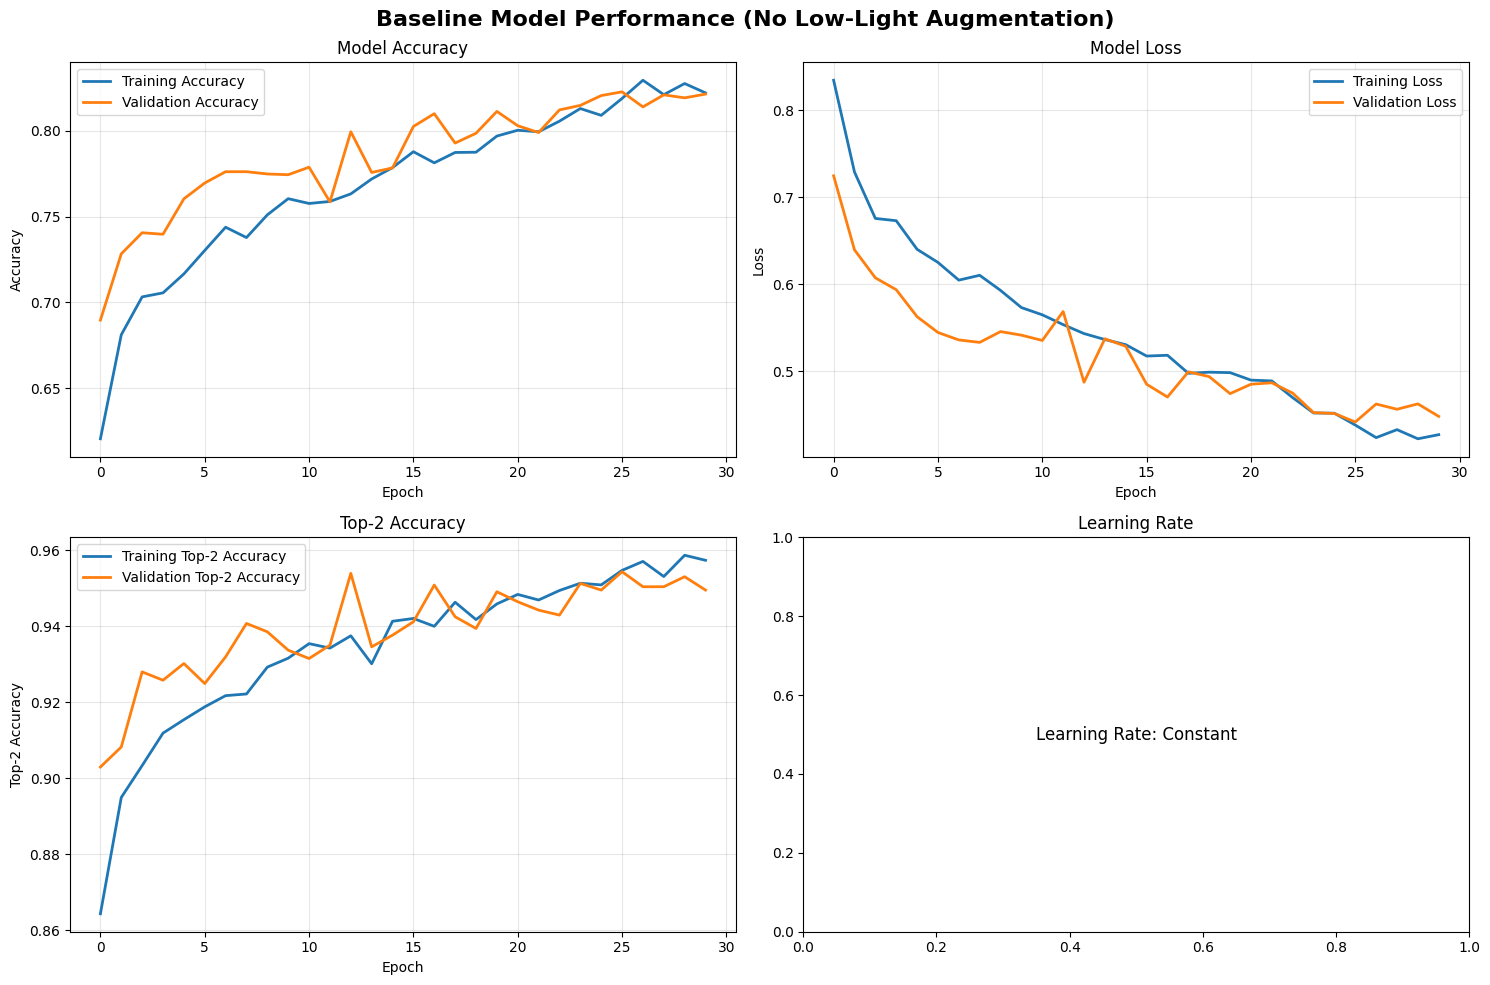

In [13]:
print("Step 8: Plotting and analyzing baseline results")

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Baseline Model Performance (No Low-Light Augmentation)', fontsize=16, fontweight='bold')

# Accuracy plot
axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss plot
axes[0, 1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Top-2 Accuracy plot
axes[1, 0].plot(history.history['top_2_accuracy'], label='Training Top-2 Accuracy', linewidth=2)
axes[1, 0].plot(history.history['val_top_2_accuracy'], label='Validation Top-2 Accuracy', linewidth=2)
axes[1, 0].set_title('Top-2 Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Top-2 Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning rate plot
if 'lr' in history.history:
    axes[1, 1].plot(history.history['lr'], label='Learning Rate', linewidth=2, color='red')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_yscale('log')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Learning Rate: Constant',
                   horizontalalignment='center', verticalalignment='center',
                   transform=axes[1, 1].transAxes, fontsize=12)
    axes[1, 1].set_title('Learning Rate')

plt.tight_layout()
plt.savefig('baseline_performance.png', dpi=300, bbox_inches='tight')
plt.show()


In [14]:
print("Step 9: Final baseline model evaluation")

# Calculate final metrics
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("\n" + "="*60)
print("BASELINE MODEL FINAL RESULTS")
print("="*60)
print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Training Epochs: {len(history.history['accuracy'])}")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print("="*60)

# Save final results summary
results_summary = {
    'model_type': 'baseline_normal',
    'final_training_accuracy': float(final_train_accuracy),
    'final_validation_accuracy': float(final_val_accuracy),
    'final_training_loss': float(final_train_loss),
    'final_validation_loss': float(final_val_loss),
    'best_validation_accuracy': float(max(history.history['val_accuracy'])),
    'total_epochs_trained': len(history.history['accuracy']),
    'dataset_info': {
        'training_samples': train_generator.samples,
        'validation_samples': validation_generator.samples,
        'class_names': CONFIG["class_names"]
    }
}

with open('baseline_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=4)

Step 9: Final baseline model evaluation

BASELINE MODEL FINAL RESULTS
Final Training Accuracy: 0.8220
Final Validation Accuracy: 0.8213
Final Training Loss: 0.4274
Final Validation Loss: 0.4484
Training Epochs: 30
Best Validation Accuracy: 0.8227
